# **Age And Gender Prediction Model**

Downloading Dataset Remotely through Kaggle Or download using Link in requirements.txt

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jangedoo/utkface-new")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'utkface-new' dataset.
Path to dataset files: /kaggle/input/utkface-new


Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Extract Metadata from Filenames

In [3]:
age,gender,image=[],[],[]
#Download through kaggle link in requirements.txt file
#paste the path here
path="/kaggle/input/utkface-new/crop_part1"
for file in os.listdir(path):
  age.append(int(file.split("_")[0]))
  gender.append(int(file.split("_")[1]))
  image.append(path+"/"+file)


all comp at a dataframe from clean processing

In [4]:
df=pd.DataFrame({"age":age,"gender":gender,"image_path":image})
print(df.head())

   age  gender                                         image_path
0   26       0  /kaggle/input/utkface-new/crop_part1/26_0_2_20...
1   21       1  /kaggle/input/utkface-new/crop_part1/21_1_3_20...
2   17       1  /kaggle/input/utkface-new/crop_part1/17_1_4_20...
3   76       0  /kaggle/input/utkface-new/crop_part1/76_0_0_20...
4   18       1  /kaggle/input/utkface-new/crop_part1/18_1_0_20...


Age distribution plot

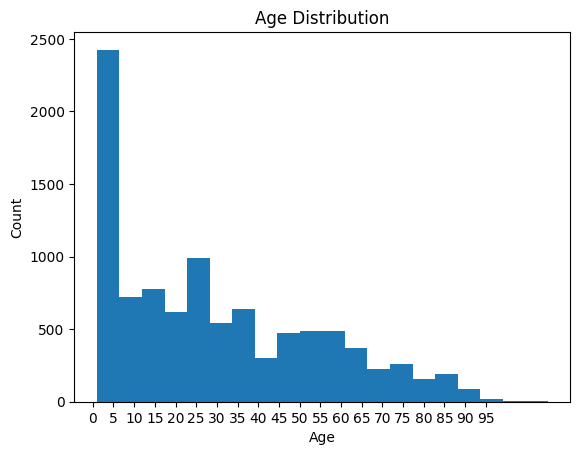

In [6]:
plt.hist(df["age"],bins=20)
plt.xticks(np.arange(0,100,5))
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")
plt.show()

Very high number of data for age group between 1-4, model may overfit, And very few data for age >80 model may underfit, so lets filter it out

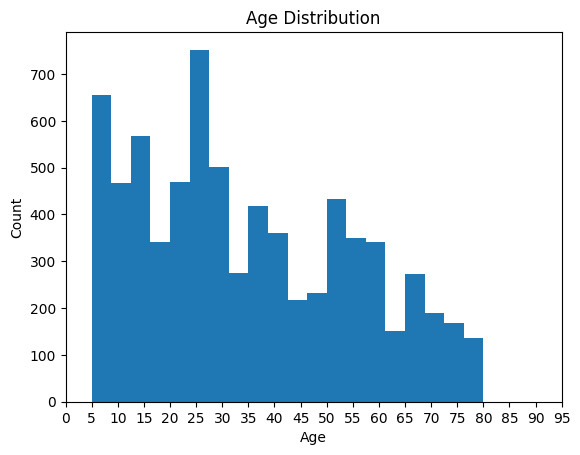

In [7]:
df=df.loc[(df['age']>=5) & (df['age']<=80) , ['age','gender','image_path'] ]
plt.hist(df["age"],bins=20)
plt.xticks(np.arange(0,100,5))
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")
plt.show()

Now this looks better, lets contiune to Loading image file for model using CV

In [8]:
import cv2

def load_image(path):
  img=cv2.imread(path)
  img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
  img=cv2.resize(img,(200,200))
  img=img/255.0
  img = np.expand_dims(img, axis=0)
  return img


In [9]:
IMG_SIZE=200

Splitting data for train and test 80:20

In [10]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

Create Data for model to fit

In [11]:
import tensorflow as tf

def create_data(df,batch_size=32):
  paths=df['image_path'].values
  ages=df['age'].values
  genders=df['gender'].values

  def load(path,age,gender):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, {"age": age, "gender": gender}

  dataset = tf.data.Dataset.from_tensor_slices((paths, ages, genders))
  dataset = dataset.map(lambda p, a, g: load(p, a, g))
  dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
  return dataset

train_ds = create_data(train_df)
test_ds  = create_data(test_df)


Model Architecture (VGG16 Transfer Learning)

In [12]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.models import Model

vggnet=VGG16(include_top=False,input_shape=(IMG_SIZE,IMG_SIZE,3))
vggnet.trainable=False
for Layers in vggnet.layers[-4:]:
  Layers.trainable=True

out=vggnet.layers[-1].output
flat=Flatten()(out)

dense0A=Dense(128,activation="relu")(flat)
dense0B=Dense(128,activation="relu")(flat)

dense1A=Dense(128,activation="relu")(dense0A)
dense1B=Dense(128,activation="relu")(dense0B)

dense2A=Dense(64,activation="relu")(dense1A)
dense2B=Dense(64,activation="relu")(dense1B)

dropoutA=Dropout(0.5)(dense2A)
dropoutB=Dropout(0.5)(dense2B)

outputA=Dense(1,activation='linear',name="age")(dropoutA)
outputB=Dense(1,activation="sigmoid",name="gender")(dropoutB)

model=Model(inputs=vggnet.input,outputs=[outputA,outputB])



58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model Structure

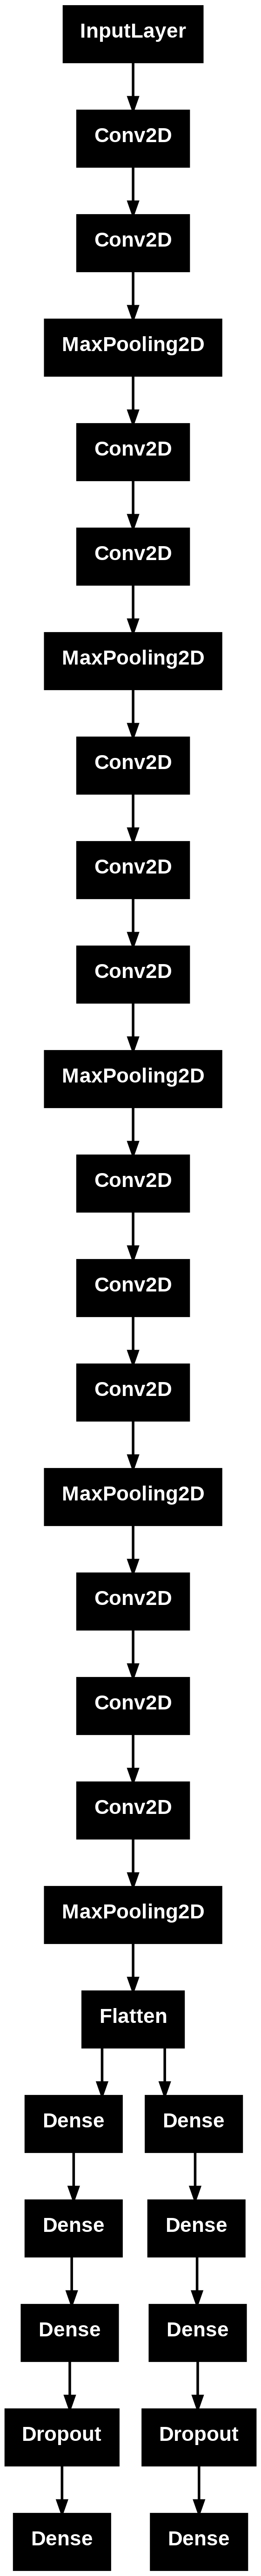

In [13]:
from tensorflow.keras.utils import plot_model
plot_model(model)

Compiler with ADAM optimizer and loss function MAE and binary Crossentropy

In [14]:
model.compile(
    optimizer="adam",
    loss={"age":'mae',"gender":"binary_crossentropy"},
    metrics={"age":"mae","gender":"accuracy"},
    loss_weights={"age":0.5,"gender":1})

Traning with Earlystopping if accuracy does not increases

In [ ]:
model.fit(train_ds,validation_data=test_ds,epochs=10,
          callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)
    ])
model.save('model_AGE_GENDER.keras')

Epoch 1/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 77s 321ms/step - age_loss: 20.3989 - age_mae: 20.3991 - gender_accuracy: 0.5499 - gender_loss: 0.9579 - loss: 11.1574 - val_age_loss: 10.0285 - val_age_mae: 10.0248 - val_gender_accuracy: 0.7077 - val_gender_loss: 0.5800 - val_loss: 5.5931 - learning_rate: 0.0010
Epoch 2/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 41s 225ms/step - age_loss: 11.2721 - age_mae: 11.2720 - gender_accuracy: 0.7252 - gender_loss: 0.5442 - loss: 6.1802 - val_age_loss: 7.9045 - val_age_mae: 7.8974 - val_gender_accuracy: 0.8426 - val_gender_loss: 0.3699 - val_loss: 4.3193 - learning_rate: 0.0010
Epoch 3/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 43s 235ms/step - age_loss: 10.2277 - age_mae: 10.2277 - gender_accuracy: 0.8314 - gender_loss: 0.3976 - loss: 5.5114 - val_age_loss: 7.4329 - val_age_mae: 7.4226 - val_gender_accuracy: 0.8658 - val_gender_loss: 0.3042 - val_loss: 4.0164 - learning_rate: 0.0010
Epoch 4/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 45s 244ms/step - age_loss: 9.4800 - age_mae: 9.4799 - 

Predict using the above ONG model

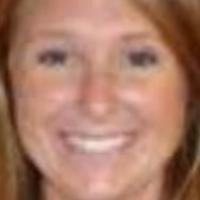

Age 26
Gender Female
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Age Predicted: [22.]
Gender Predicted:  Female


In [ ]:
from IPython.display import Image, display
from numpy import random
n=np.random.randint(0,len(df))
T=df['image_path'][n]
display(Image(filename=df['image_path'][n]))
print("Age", df['age'][n])
sex= "Female" if df['gender'][n]>=0.5 else "Male"
print("Gender", sex)

im=load_image(T)

age_pred,gender_pred=model.predict(im)
print("Age Predicted:", np.round(age_pred[0]))
sex_pred= "Female" if gender_pred>=0.5 else "Male"
print("Gender Predicted: ", sex_pred)

Predict using saved trained model

/kaggle/input/utkface-new/crop_part1/26_1_4_20170105164223948.jpg.chip.jpg


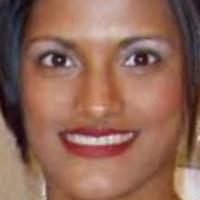

Age 26
Gender Female
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Age Predicted: [28.]
Gender Predicted:  Female


In [15]:
from tensorflow.keras.models import load_model
#Download the trained model and paste the Link here
model=load_model('/kaggle/model/model_AGE_GENDER.keras')
import warnings
warnings.filterwarnings('ignore')
from IPython.display import Image, display
from numpy import random
n=np.random.randint(0,len(df))
T=df['image_path'][n]
print(T)
display(Image(filename=df['image_path'][n]))
print("Age", df['age'][n])
sex= "Female" if df['gender'][n]>=0.5 else "Male"
print("Gender", sex)
im=load_image(T)
age_pred,gender_pred=model.predict(im)
print("Age Predicted:", np.round(age_pred[0]))
sex_pred= "Female" if gender_pred>=0.5 else "Male"
print("Gender Predicted: ", sex_pred)

TF version to replicate the project

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.19.0
